# 피부 특징 학습 — 모공·주름·색소·여드름·피부나이

부위 크롭 1장을 넣으면 그 부위의 피부 특징들을 한 번에 예측한다.
백본(ConvNeXt) 하나를 모든 부위·항목이 공유하고, 항목마다 작은 헤드가 붙는다.

**정답이 있는 칸만 학습한다.** 부위마다 있는 항목이 다르다.

| | 이마 | 미간 | 눈가 좌/우 | 볼 좌/우 |
|---|:-:|:-:|:-:|:-:|
| 모공 | · | · | · | 등급 + 개수 |
| 주름 | 등급 | 등급 | 등급 + Ra | · |
| 색소 | 등급 | · | · | 등급 |
| 여드름 | 개수 | · | · | 개수 |
| 피부나이 | 나이 | 나이 | 나이 | 나이 |

**한 샘플 = 크롭 1장.** 사람 단위로 학습하면 샘플이 800개뿐인데, 크롭 단위면 9,000개가 된다.
추론할 때 같은 (사람, 부위)의 여러 사진 예측을 평균하면 사람 단위 예측이 된다.

**나눌 때는 사람 단위.** 같은 사람의 사진은 정답이 같아서 섞이면 점수가 부풀려진다.

구성: ① 설정 → ② 데이터 → ③ 학습 함수 → **A. 하이퍼파라미터 실험** → **B. 최종 학습** → **C. 테스트 평가**

## ① 설정

실험은 이 `CFG`의 값을 바꿔가며 한다. 모델 구조만 `model.py`에 있다.

In [1]:
import csv
import importlib
import json
import sys
import time
from collections import defaultdict
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader

import model as model_module

importlib.reload(model_module)
from model import SkinModel

# 전처리 모듈에서 캔버스 크기를 가져온다 (전처리와 학습이 같은 규칙을 쓰도록)
ROOT = Path.cwd().parent
sys.path.append(str(ROOT / "data_preprocessing"))
import face_regions

importlib.reload(face_regions)
from face_regions import CANVAS

# Dataset은 DataLoader 워커(윈도우는 새 프로세스)가 찾을 수 있도록 data.py에 둔다
import data as data_module

importlib.reload(data_module)
from data import PIXEL_MEAN, PIXEL_STD, RegionBatchSampler, RegionDataset

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

CROP_DIR = ROOT / "data" / "01.원천데이터"
INDEX_PATH = ROOT / "data" / "index.csv"
LABEL_PATH = ROOT / "data" / "02.정답지데이터" / "labels_region.csv"
AILAB_DIR = ROOT / "ailabtools" / "test_set"
OUT_DIR = Path.cwd() / "outputs"
OUT_DIR.mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
USE_AMP = DEVICE == "cuda"  # NVIDIA에서는 혼합정밀도로 2배 빨라진다

REGIONS = ["forehead", "glabella", "l_eye", "r_eye", "l_cheek", "r_cheek"]

# 항목 → (정답 열, 정답이 있는 부위, log 변환 여부)
#   log=True: 개수처럼 한쪽으로 치우친 값은 log(1+x)로 바꿔 학습한다
TASKS = {
    "pore_count": dict(column="pore_count", regions=["l_cheek", "r_cheek"], log=True),
    "pore_grade": dict(column="pore_grade", regions=["l_cheek", "r_cheek"], log=False),
    "wrinkle_grade": dict(column="wrinkle_grade", regions=["forehead", "glabella", "l_eye", "r_eye"], log=False),
    "wrinkle_ra": dict(column="wrinkle_ra", regions=["l_eye", "r_eye"], log=False),
    "pigment_grade": dict(column="pigment_grade", regions=["forehead", "l_cheek", "r_cheek"], log=False),
    "acne_count": dict(column="acne_count", regions=["forehead", "l_cheek", "r_cheek"], log=True),
    "age": dict(column="age", regions=REGIONS, log=False),
}
TASK_NAMES = list(TASKS)

CFG = dict(
    views=["F"],                 # 실험용은 정면만. 최종 학습은 ["F", "L", "R"]
    min_skin_px=20_000,          # 피부가 이보다 적은 크롭은 제외 (가려졌거나 추출이 이상한 경우)
    mirror_right=True,           # 오른쪽 부위를 좌우 반전해 왼쪽과 방향을 맞춘다
    detached_tasks=(),           # 백본에 영향을 주지 않을 항목 (예: ("age",))
    # 모델
    backbone="convnext_tiny.fb_in22k_ft_in1k",
    freeze_stages=2, head_hidden=256, head_act="gelu", dropout=0.2,
    # 학습
    folds=5, epochs=15, patience=4, batch_size=8,
    lr_backbone=2e-5, lr_head=2e-4, weight_decay=0.05,
    # 증강 (흐림·강한 색 변화는 모공·색소 신호를 망가뜨려서 쓰지 않는다)
    aug_rotate=10, aug_scale=0.05, aug_bright=0.1,
    # 로더 워커 수 (학습/검증). 학습은 6개면 GPU가 데이터를 기다리지 않는다.
    # 워커 1개당 RAM 약 0.5GB라 16GB PC에서는 이보다 늘리면 스왑이 생긴다
    num_workers=6, valid_workers=2, seed=42,
)

print(f"장치 {DEVICE} (AMP {'사용' if USE_AMP else '미사용'}) | 백본 {CFG['backbone']}")
print(f"부위 {REGIONS}")
print(f"항목 {TASK_NAMES}")

c:\Users\user\Desktop\소마\skin_analysis_ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


장치 cuda (AMP 사용) | 백본 convnext_tiny.fb_in22k_ft_in1k
부위 ['forehead', 'glabella', 'l_eye', 'r_eye', 'l_cheek', 'r_cheek']
항목 ['pore_count', 'pore_grade', 'wrinkle_grade', 'wrinkle_ra', 'pigment_grade', 'acne_count', 'age']


## ② 데이터

저장된 크롭은 원본 해상도다. 읽은 뒤 **증강 → 배율 통일 → 캔버스** 순서로 처리한다.
회전을 원본 크기에서 하는 이유는, 이미 작아진 이미지에서 회전하면 질감이 절반으로 뭉개지기 때문이다.

In [2]:
def load_rows(cfg):
    """index.csv와 정답을 합쳐 크롭 목록을 만든다. 테스트 165명은 따로 뺀다."""
    labels = {}
    with open(LABEL_PATH, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            labels[(row["subject"], row["region"])] = {
                task: float(row[spec["column"]])
                for task, spec in TASKS.items()
                if row[spec["column"]] and row["region"] in spec["regions"]
            }

    test_subjects = {s["subject_id"]
                     for s in json.loads((AILAB_DIR / "test_subjects_165.json").read_text(encoding="utf-8"))["subjects"]}

    rows, test_rows = [], []
    with open(INDEX_PATH, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            if row["status"] != "ok" or row["region"] not in REGIONS or row["view"] not in cfg["views"]:
                continue
            if int(row["skin_px"]) < cfg["min_skin_px"]:
                continue
            targets = labels.get((row["subject"], row["region"]))
            if not targets:
                continue
            sample = dict(subject=row["subject"], device=row["device"], view=row["view"], region=row["region"],
                          file=row["file"], face_h=float(row["face_h"]), targets=targets)
            (test_rows if row["subject"] in test_subjects else rows).append(sample)
    return rows, test_rows


def transform(task, value):
    """치우친 값은 log를 씌워 분포를 고르게 만든다."""
    return float(np.log1p(value)) if TASKS[task]["log"] else float(value)


def inverse(task, value):
    return float(np.expm1(value)) if TASKS[task]["log"] else float(value)


def target_stats(rows):
    """항목마다 평균·표준편차. 검증 정보가 새지 않게 학습 rows만 넣을 것.

    항목별로만 구한다. 한 항목 안에서는 부위가 달라도 단위가 같고(주름 등급은 어디든 0~6),
    부위별 차이(볼이 이마보다 색소가 짙다)는 모델이 배워야 할 실제 정보다.
    반면 항목 간 단위 차이는 549배까지 나서, 표준화하지 않으면 큰 항목이 손실을 독차지한다.
    """
    collected = defaultdict(list)
    for row in rows:
        for task, value in row["targets"].items():
            collected[task].append(transform(task, value))
    return {task: (float(np.mean(v)), float(np.std(v)) or 1.0) for task, v in collected.items()}


def make_loader(rows, stats, cfg, train):
    dataset = RegionDataset(rows, stats, cfg, TASKS, CROP_DIR, train=train)
    sampler = RegionBatchSampler(rows, cfg["batch_size"], shuffle=train, drop_last=train, seed=cfg["seed"])
    workers = cfg["num_workers"] if train else cfg["valid_workers"]
    return DataLoader(dataset, batch_sampler=sampler, num_workers=workers,
                      persistent_workers=workers > 0, pin_memory=DEVICE == "cuda")


def split_folds(rows, folds):
    """사람 단위로 나눈다. 같은 사람의 사진은 정답이 같아서 섞이면 점수가 부풀려진다."""
    groups = [r["subject"] for r in rows]
    return [([rows[i] for i in tr], [rows[i] for i in va])
            for tr, va in GroupKFold(n_splits=folds).split(rows, groups=groups)]

In [3]:
rows, test_rows = load_rows(CFG)
folds = split_folds(rows, CFG["folds"])

print(f"학습 크롭 {len(rows):,}개 (사람 {len({r['subject'] for r in rows}):,}명)")
print(f"테스트 보관 {len(test_rows):,}개 (사람 {len({r['subject'] for r in test_rows}):,}명) — 어디에도 쓰지 않는다")
print("\n항목별 학습 칸 수:", {t: sum(t in r["targets"] for r in rows) for t in TASK_NAMES})
print("부위별 크롭 수:", {g: sum(r["region"] == g for r in rows) for g in REGIONS})
print("\n항목별 기준값 (평균, 표준편차):")
for task, (mean, std) in target_stats(rows).items():
    print(f"  {task:14s} {mean:8.3f} {std:8.3f}" + ("   ← log(1+x) 기준" if TASKS[task]["log"] else ""))

학습 크롭 9,109개 (사람 800명)
테스트 보관 1,894개 (사람 165명) — 어디에도 쓰지 않는다

항목별 학습 칸 수: {'pore_count': 3170, 'pore_grade': 3170, 'wrinkle_grade': 5939, 'wrinkle_ra': 2821, 'pigment_grade': 4755, 'acne_count': 4755, 'age': 9109}
부위별 크롭 수: {'forehead': 1585, 'glabella': 1533, 'l_eye': 1427, 'r_eye': 1394, 'l_cheek': 1585, 'r_cheek': 1585}

항목별 기준값 (평균, 표준편차):
  wrinkle_grade     2.283    1.740
  pigment_grade     1.942    1.217
  acne_count        0.323    0.573   ← log(1+x) 기준
  age              41.876   16.047
  wrinkle_ra       21.905    5.548
  pore_count        6.660    0.662   ← log(1+x) 기준
  pore_grade        2.039    0.846


## ③ 학습·평가 함수

- **손실**: 항목 안에서 평균 → 항목끼리 평균. 칸 수가 많은 항목이 독차지하지 않게 한다.
- **모델 선택**: 검증 loss(학습 loss와 같은 규칙)가 가장 낮은 에폭을 남긴다. 7개 항목을 같은 비중으로 본다.
- **보고**: 같은 (사람, 부위)의 여러 사진 예측을 평균한 뒤 스피어맨·피어슨·MAE를 잰다. 에폭마다 history에 남는다.

In [4]:
LOSS_FN = nn.SmoothL1Loss()  # 이상치(모공 2000개 같은 경우)에 덜 휘둘린다


def masked_loss(pred, target, valid, loss_fn):
    """정답이 있는 칸만 손실에 넣는다."""
    losses = [loss_fn(pred[valid[:, t] > 0, t], target[valid[:, t] > 0, t])
              for t in range(pred.shape[1]) if (valid[:, t] > 0).any()]
    return torch.stack(losses).mean() if losses else pred.sum() * 0


def predict(net, loader):
    net.eval()
    preds, targets, valids, indices = [], [], [], []
    with torch.no_grad():
        for images, target, valid, index in loader:
            with torch.autocast(DEVICE, dtype=torch.float16, enabled=USE_AMP): #?이게 뭐한느거임 넷이뭔지
                out = net(images.to(DEVICE))
            preds.append(out.float().cpu().numpy())
            targets.append(target.numpy())
            valids.append(valid.numpy())
            indices.append(index.numpy())
    return np.concatenate(preds), np.concatenate(targets), np.concatenate(valids), np.concatenate(indices)


def evaluate(net, loader, rows, stats, return_predictions=False):
    """항목별 성능과 검증 loss.

    성능은 사람·부위 단위로 예측을 평균한 뒤 잰다.
    검증 loss는 학습 loss와 같은 규칙(항목 안 평균 → 항목끼리 평균)으로 검증 크롭 전체에서 구한다.
    """
    preds, targets, valids, indices = predict(net, loader)
    loss = float(masked_loss(torch.from_numpy(preds), torch.from_numpy(targets), torch.from_numpy(valids), LOSS_FN))
    results, predictions = {}, {}
    for t, task in enumerate(TASK_NAMES):
        mean, std = stats[task]
        grouped, truth = defaultdict(list), {}
        for pred, valid, i in zip(preds[:, t], valids[:, t], indices):
            if not valid:
                continue
            row = rows[i]
            key = (row["subject"], row["region"])
            grouped[key].append(inverse(task, pred * std + mean))
            truth[key] = row["targets"][task]
        if len(grouped) < 10:
            continue
        keys = list(grouped)
        pred_mean = np.array([np.mean(grouped[k]) for k in keys])
        actual = np.array([truth[k] for k in keys])
        results[task] = dict(spearman=float(spearmanr(pred_mean, actual).statistic),
                             pearson=float(pearsonr(pred_mean, actual).statistic),
                             mae=float(np.abs(pred_mean - actual).mean()), n=len(keys))
        predictions[task] = (keys, pred_mean, actual)
    return (results, loss, predictions) if return_predictions else (results, loss)


def mean_spearman(results):
    return float(np.mean([r["spearman"] for r in results.values()])) if results else 0.0


def train_fold(train_rows, valid_rows, cfg, epochs=None, verbose=True, save_path=None):
    """한 fold 학습. 검증 loss가 가장 낮았던 시점의 결과를 돌려준다."""
    epochs = epochs or cfg["epochs"]
    stats = target_stats(train_rows)  # 검증 fold 정보는 쓰지 않는다
    train_loader = make_loader(train_rows, stats, cfg, train=True)
    valid_loader = make_loader(valid_rows, stats, cfg, train=False)

    torch.manual_seed(cfg["seed"])
    net = SkinModel(TASK_NAMES, backbone=cfg["backbone"], freeze_stages=cfg["freeze_stages"],
                    head_hidden=cfg["head_hidden"], head_act=cfg["head_act"], dropout=cfg["dropout"],
                    detached_tasks=cfg["detached_tasks"]).to(DEVICE)
    optimizer = torch.optim.AdamW(net.param_groups(cfg["lr_backbone"], cfg["lr_head"]),
                                  weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs * len(train_loader))
    scaler = torch.amp.GradScaler(DEVICE, enabled=USE_AMP)

    best = dict(loss=float("inf"), epoch=0, results={}, history=[], stats=stats)
    bad_epochs = 0
    for epoch in range(1, epochs + 1):
        net.train()
        started, total = time.time(), 0.0
        for images, targets, valid, _ in train_loader:
            optimizer.zero_grad()
            with torch.autocast(DEVICE, dtype=torch.float16, enabled=USE_AMP):
                loss = masked_loss(net(images.to(DEVICE)), targets.to(DEVICE), valid.to(DEVICE), LOSS_FN)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            total += loss.item()

        results, val_loss = evaluate(net, valid_loader, valid_rows, stats)
        best["history"].append(dict(epoch=epoch, train_loss=total / len(train_loader), val_loss=val_loss,
                                    **{f"{task}_{metric}": r[metric] for task, r in results.items()
                                       for metric in ("spearman", "pearson", "mae")}))
        if verbose:
            summary = "  ".join(f"{k[:9]} {v['spearman']:.3f}" for k, v in results.items())
            print(f"  epoch {epoch:2d} loss 학습 {total / len(train_loader):.4f} 검증 {val_loss:.4f} | {summary} | "
                  f"평균 {mean_spearman(results):.3f} ({time.time() - started:.0f}초)", flush=True)

        if val_loss < best["loss"]:
            best.update(loss=val_loss, epoch=epoch, results=results)
            if save_path:
                torch.save({"model": net.state_dict(), "stats": stats, "cfg": cfg}, save_path)
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= cfg["patience"]:
                if verbose:
                    print(f"  {cfg['patience']}번 좋아지지 않아 중단")
                break
    return best


print(SkinModel(TASK_NAMES, pretrained=False).summary())

전체 29,199,975 / 학습 27,964,935 / 헤드 1,379,847 (4.7%) | 항목 7개


# A. 하이퍼파라미터 실험

**원칙**
- **한 번에 하나만 바꾼다.** 격자 탐색은 5항목 × 3가지 = 243번이라 불가능하다.
- **fold 0, 같은 seed로 고정**해 비교한다.
- 실험용은 정면만 + 1 fold + 15에폭(조기 종료). RTX 5070 기준 설정당 최대 약 20분.

**영향이 큰 순서**: 학습률 > 동결 단계 > 증강 강도 > 헤드 구조.
헤드는 7개를 합쳐도 전체 파라미터의 4.7%라 대개 차이가 오차 범위 안에 들어간다. 그래서 맨 마지막이다.

In [5]:
RESULT_PATH = OUT_DIR / "tuning.csv"
train_rows, valid_rows = folds[0]  # 실험은 항상 fold 0으로 고정
print(f"fold 0: 학습 {len(train_rows):,} / 검증 {len(valid_rows):,} "
      f"(사람 {len({r['subject'] for r in train_rows})} / {len({r['subject'] for r in valid_rows})})")


def run_experiment(name, **overrides):
    """CFG를 임시로 바꿔 fold 0을 학습하고 결과를 tuning.csv에 한 줄 추가한다."""
    cfg = {**CFG, **overrides}
    print(f"\n=== {name} === {overrides}")
    started = time.time()
    best = train_fold(train_rows, valid_rows, cfg)

    result = dict(name=name, when=datetime.now().strftime("%m-%d %H:%M"),
                  minutes=round((time.time() - started) / 60, 1), epochs=cfg["epochs"], best_epoch=best["epoch"],
                  val_loss=round(best["loss"], 4), mean=round(mean_spearman(best["results"]), 4),
                  **{task: round(r["spearman"], 4) for task, r in best["results"].items()},
                  **{k: str(v) for k, v in overrides.items()})

    old = list(csv.DictReader(open(RESULT_PATH, newline="", encoding="utf-8"))) if RESULT_PATH.exists() else []
    fields = list(dict.fromkeys([f for r in old for f in r] + list(result)))
    with open(RESULT_PATH, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        writer.writerows(old + [result])

    print(f"→ {name}: 검증 loss {result['val_loss']:.4f}, 평균 스피어맨 {result['mean']:.3f} ({result['minutes']:.0f}분)")
    return result


def show_results():
    if not RESULT_PATH.exists():
        print("아직 실험 결과가 없다.")
        return []
    results = list(csv.DictReader(open(RESULT_PATH, newline="", encoding="utf-8")))
    fixed = {"name", "when", "minutes", "epochs", "best_epoch", "val_loss", "mean"}
    print(f"{'실험':20s} {'검증loss':>8s} {'평균':>7s} {'분':>5s}  변경한 설정")
    for r in results:
        changed = {k: v for k, v in r.items() if k not in fixed and k not in TASK_NAMES and v}
        print(f"{r['name']:20s} {float(r['val_loss']):8.4f} {float(r['mean']):7.3f} "
              f"{float(r['minutes']):5.0f}  {changed}")
    return results

fold 0: 학습 7,287 / 검증 1,822 (사람 640 / 160)


### 0단계. 오차 범위 재기 (가장 먼저)

검증이 160명이라 결과가 우연히 흔들린다. 같은 설정을 seed만 바꿔 두 번 돌려
그 폭을 먼저 확인해야 "이 설정이 더 낫다"를 판단할 수 있다.

In [6]:
run_experiment("기준")
run_experiment("기준(seed 43)", seed=43)

results = show_results()
if len(results) >= 2:
    gap = abs(float(results[-1]["val_loss"]) - float(results[-2]["val_loss"]))
    print(f"\nseed만 달라서 생긴 검증 loss 차이: {gap:.4f} → 이보다 작은 차이는 의미 없다고 본다.")


=== 기준 === {}
  epoch  1 loss 학습 0.2304 검증 0.2138 | pore_coun 0.796  pore_grad 0.565  wrinkle_g 0.832  wrinkle_r 0.646  pigment_g 0.820  acne_coun 0.412  age 0.903 | 평균 0.711 (80초)
  epoch  2 loss 학습 0.1668 검증 0.1940 | pore_coun 0.816  pore_grad 0.587  wrinkle_g 0.846  wrinkle_r 0.654  pigment_g 0.834  acne_coun 0.541  age 0.923 | 평균 0.743 (59초)
  epoch  3 loss 학습 0.1478 검증 0.1878 | pore_coun 0.828  pore_grad 0.595  wrinkle_g 0.849  wrinkle_r 0.627  pigment_g 0.837  acne_coun 0.542  age 0.923 | 평균 0.743 (59초)
  epoch  4 loss 학습 0.1327 검증 0.1850 | pore_coun 0.816  pore_grad 0.563  wrinkle_g 0.851  wrinkle_r 0.687  pigment_g 0.841  acne_coun 0.541  age 0.929 | 평균 0.747 (59초)
  epoch  5 loss 학습 0.1184 검증 0.1879 | pore_coun 0.839  pore_grad 0.542  wrinkle_g 0.857  wrinkle_r 0.678  pigment_g 0.847  acne_coun 0.548  age 0.932 | 평균 0.749 (60초)
  epoch  6 loss 학습 0.1048 검증 0.1836 | pore_coun 0.839  pore_grad 0.559  wrinkle_g 0.856  wrinkle_r 0.662  pigment_g 0.847  acne_coun 0.512  age 0.934 

### 1단계. 학습률 (영향이 가장 큼)

기준(백본 2e-5)의 ×1/4, ×1/2, ×2, ×4를 돌린다. ×1은 0단계의 "기준"을 그대로 쓴다.
학습률은 배율이 결과를 좌우해서 등간격이 아니라 로그 간격으로 나눈다. 헤드는 항상 백본의 10배.

In [7]:
for scale in (0.25, 0.5, 2, 4):
    lr = CFG["lr_backbone"] * scale
    run_experiment(f"학습률 x{scale}", lr_backbone=lr, lr_head=lr * 10)
show_results();


=== 학습률 x0.25 === {'lr_backbone': 5e-06, 'lr_head': 5e-05}


  epoch  1 loss 학습 0.2520 검증 0.2305 | pore_coun 0.672  pore_grad 0.525  wrinkle_g 0.812  wrinkle_r 0.609  pigment_g 0.795  acne_coun 0.445  age 0.873 | 평균 0.676 (72초)
  epoch  2 loss 학습 0.1841 검증 0.2073 | pore_coun 0.790  pore_grad 0.555  wrinkle_g 0.830  wrinkle_r 0.641  pigment_g 0.818  acne_coun 0.522  age 0.905 | 평균 0.723 (58초)
  epoch  3 loss 학습 0.1649 검증 0.1957 | pore_coun 0.811  pore_grad 0.575  wrinkle_g 0.839  wrinkle_r 0.655  pigment_g 0.827  acne_coun 0.534  age 0.913 | 평균 0.736 (58초)
  epoch  4 loss 학습 0.1535 검증 0.1927 | pore_coun 0.818  pore_grad 0.565  wrinkle_g 0.837  wrinkle_r 0.661  pigment_g 0.832  acne_coun 0.530  age 0.919 | 평균 0.737 (58초)
  epoch  5 loss 학습 0.1435 검증 0.1873 | pore_coun 0.827  pore_grad 0.571  wrinkle_g 0.846  wrinkle_r 0.659  pigment_g 0.836  acne_coun 0.534  age 0.921 | 평균 0.742 (58초)
  epoch  6 loss 학습 0.1361 검증 0.1875 | pore_coun 0.832  pore_grad 0.578  wrinkle_g 0.848  wrinkle_r 0.653  pigment_g 0.834  acne_coun 0.534  age 0.923 | 평균 0.743 (60초

### 2단계. 백본을 얼마나 얼릴지

`0`=거의 전부 학습, `2`=앞 4.4% 고정(지금), `3`=앞 44% 고정.
데이터가 800명뿐이라 많이 얼리는 쪽이 유리할 수 있다.

In [8]:
run_experiment("동결 없음", freeze_stages=0)
run_experiment("동결 3단계", freeze_stages=3)
show_results();


=== 동결 없음 === {'freeze_stages': 0}
  epoch  1 loss 학습 0.2321 검증 0.2195 | pore_coun 0.790  pore_grad 0.568  wrinkle_g 0.846  wrinkle_r 0.637  pigment_g 0.817  acne_coun 0.465  age 0.888 | 평균 0.716 (95초)
  epoch  2 loss 학습 0.1685 검증 0.1929 | pore_coun 0.816  pore_grad 0.589  wrinkle_g 0.845  wrinkle_r 0.642  pigment_g 0.828  acne_coun 0.538  age 0.923 | 평균 0.740 (80초)
  epoch  3 loss 학습 0.1477 검증 0.1880 | pore_coun 0.828  pore_grad 0.609  wrinkle_g 0.840  wrinkle_r 0.641  pigment_g 0.833  acne_coun 0.541  age 0.926 | 평균 0.745 (80초)
  epoch  4 loss 학습 0.1321 검증 0.1848 | pore_coun 0.820  pore_grad 0.564  wrinkle_g 0.855  wrinkle_r 0.677  pigment_g 0.843  acne_coun 0.538  age 0.928 | 평균 0.746 (79초)
  epoch  5 loss 학습 0.1156 검증 0.1889 | pore_coun 0.831  pore_grad 0.558  wrinkle_g 0.856  wrinkle_r 0.676  pigment_g 0.846  acne_coun 0.514  age 0.934 | 평균 0.745 (80초)
  epoch  6 loss 학습 0.1023 검증 0.1831 | pore_coun 0.834  pore_grad 0.557  wrinkle_g 0.853  wrinkle_r 0.670  pigment_g 0.842  acne_c

### 3단계. 증강 강도

약하면 외우고, 강하면 신호가 망가진다.
회전·배율·밝기를 "강도" 하나로 묶어 기준(10°, ±5%, ±10%)의 ×0(증강 없음), ×0.5, ×2, ×3을 돌린다. ×1은 0단계의 "기준".
×4(회전 40°, 밝기 ±40%)는 색소 신호를 망가뜨리는 범위라 뺐다.

In [9]:
for scale in (0, 0.5, 2, 3):
    run_experiment(f"증강 x{scale}", aug_rotate=round(CFG["aug_rotate"] * scale, 4),
                   aug_scale=round(CFG["aug_scale"] * scale, 4), aug_bright=round(CFG["aug_bright"] * scale, 4))
show_results();


=== 증강 x0 === {'aug_rotate': 0, 'aug_scale': 0.0, 'aug_bright': 0.0}
  epoch  1 loss 학습 0.2270 검증 0.2172 | pore_coun 0.803  pore_grad 0.565  wrinkle_g 0.834  wrinkle_r 0.650  pigment_g 0.825  acne_coun 0.474  age 0.909 | 평균 0.723 (69초)
  epoch  2 loss 학습 0.1615 검증 0.1929 | pore_coun 0.819  pore_grad 0.593  wrinkle_g 0.842  wrinkle_r 0.663  pigment_g 0.834  acne_coun 0.544  age 0.916 | 평균 0.744 (55초)
  epoch  3 loss 학습 0.1367 검증 0.1842 | pore_coun 0.837  pore_grad 0.586  wrinkle_g 0.844  wrinkle_r 0.662  pigment_g 0.840  acne_coun 0.552  age 0.927 | 평균 0.750 (56초)
  epoch  4 loss 학습 0.1146 검증 0.1864 | pore_coun 0.824  pore_grad 0.516  wrinkle_g 0.839  wrinkle_r 0.685  pigment_g 0.843  acne_coun 0.538  age 0.930 | 평균 0.739 (55초)
  epoch  5 loss 학습 0.0932 검증 0.1896 | pore_coun 0.832  pore_grad 0.544  wrinkle_g 0.841  wrinkle_r 0.673  pigment_g 0.846  acne_coun 0.511  age 0.929 | 평균 0.739 (55초)
  epoch  6 loss 학습 0.0733 검증 0.1954 | pore_coun 0.839  pore_grad 0.534  wrinkle_g 0.839  wrinkl

### 4단계. 헤드 구조 (영향이 가장 작음)

드롭아웃은 기준(0.2) 외에 0(없음), 0.1, 0.4를 돌린다. 드롭아웃은 헤드 은닉층에만 있어서 `head_hidden=0`이면 효과가 없다.

In [10]:
run_experiment("헤드 1층", head_hidden=0)
run_experiment("헤드 512", head_hidden=512)
for p in (0, 0.1, 0.4):
    run_experiment(f"드롭아웃 {p}", dropout=p)
show_results();


=== 헤드 1층 === {'head_hidden': 0}
  epoch  1 loss 학습 0.2383 검증 0.2178 | pore_coun 0.767  pore_grad 0.530  wrinkle_g 0.832  wrinkle_r 0.642  pigment_g 0.821  acne_coun 0.440  age 0.902 | 평균 0.705 (80초)
  epoch  2 loss 학습 0.1691 검증 0.1938 | pore_coun 0.823  pore_grad 0.561  wrinkle_g 0.841  wrinkle_r 0.667  pigment_g 0.834  acne_coun 0.529  age 0.921 | 평균 0.740 (58초)
  epoch  3 loss 학습 0.1485 검증 0.1878 | pore_coun 0.832  pore_grad 0.564  wrinkle_g 0.845  wrinkle_r 0.668  pigment_g 0.841  acne_coun 0.541  age 0.920 | 평균 0.745 (58초)
  epoch  4 loss 학습 0.1329 검증 0.1917 | pore_coun 0.809  pore_grad 0.517  wrinkle_g 0.853  wrinkle_r 0.684  pigment_g 0.845  acne_coun 0.530  age 0.926 | 평균 0.738 (57초)
  epoch  5 loss 학습 0.1202 검증 0.1855 | pore_coun 0.835  pore_grad 0.526  wrinkle_g 0.851  wrinkle_r 0.694  pigment_g 0.851  acne_coun 0.546  age 0.932 | 평균 0.748 (57초)
  epoch  6 loss 학습 0.1070 검증 0.1852 | pore_coun 0.832  pore_grad 0.558  wrinkle_g 0.851  wrinkle_r 0.666  pigment_g 0.842  acne_cou

### 5단계. 추가 실험

- **백본 small**: tiny의 1.8배 크기. 에폭당 시간도 약 2배로 예상되어 최대 40분
- **나이 분리**: 나이는 얼굴 전체 인상으로 쉽게 맞히는 항목이라 백본을 "나이 인상" 쪽으로 끌고 갈 수 있다. 나이 헤드만 학습하고 백본에는 기울기를 흘리지 않는다
- **배치 16**: VRAM 여유(12GB 중 약 1.6GB 사용)를 활용. 학습률은 그대로 두고 배치만 바꾼다
- **weight_decay 0(없음) / 0.01 / 0.1**: 기준은 0.05. 백본 학습률이 작아 영향이 작을 수 있다

모든 실험은 기준 CFG에서 하나만 바꾼 것이다. 단계별로 이긴 설정을 합친 **조합** 실험을 마지막에 따로 돌려 확인한다.

In [11]:
run_experiment("백본 small", backbone="convnext_small.fb_in22k_ft_in1k")
run_experiment("나이 분리", detached_tasks=("age",))
run_experiment("배치 16", batch_size=16)
for wd in (0, 0.01, 0.1):
    run_experiment(f"weight_decay {wd}", weight_decay=wd)
show_results();


=== 백본 small === {'backbone': 'convnext_small.fb_in22k_ft_in1k'}
  epoch  1 loss 학습 0.2089 검증 0.2017 | pore_coun 0.839  pore_grad 0.596  wrinkle_g 0.844  wrinkle_r 0.646  pigment_g 0.833  acne_coun 0.506  age 0.919 | 평균 0.740 (103초)
  epoch  2 loss 학습 0.1561 검증 0.1894 | pore_coun 0.840  pore_grad 0.610  wrinkle_g 0.854  wrinkle_r 0.664  pigment_g 0.834  acne_coun 0.555  age 0.930 | 평균 0.755 (84초)
  epoch  3 loss 학습 0.1347 검증 0.1886 | pore_coun 0.839  pore_grad 0.627  wrinkle_g 0.849  wrinkle_r 0.634  pigment_g 0.835  acne_coun 0.534  age 0.931 | 평균 0.750 (84초)
  epoch  4 loss 학습 0.1177 검증 0.1848 | pore_coun 0.841  pore_grad 0.584  wrinkle_g 0.845  wrinkle_r 0.671  pigment_g 0.838  acne_coun 0.512  age 0.939 | 평균 0.747 (83초)
  epoch  5 loss 학습 0.1000 검증 0.1810 | pore_coun 0.849  pore_grad 0.578  wrinkle_g 0.857  wrinkle_r 0.661  pigment_g 0.849  acne_coun 0.539  age 0.937 | 평균 0.753 (83초)
  epoch  6 loss 학습 0.0829 검증 0.1843 | pore_coun 0.838  pore_grad 0.605  wrinkle_g 0.853  wrinkle_r

실험                     검증loss      평균     분  변경한 설정
기준                     0.1836   0.744    10  {}
기준(seed 43)            0.1845   0.742     9  {'seed': '43'}
학습률 x0.25              0.1853   0.748    13  {'lr_backbone': '5e-06', 'lr_head': '5e-05'}
학습률 x0.5               0.1827   0.747    10  {'lr_backbone': '1e-05', 'lr_head': '0.0001'}
학습률 x2                 0.1837   0.740    11  {'lr_backbone': '4e-05', 'lr_head': '0.0004'}
학습률 x4                 0.1850   0.746    12  {'lr_backbone': '8e-05', 'lr_head': '0.0008'}
동결 없음                  0.1831   0.743    14  {'freeze_stages': '0'}
동결 3단계                 0.1948   0.739    11  {'freeze_stages': '3'}
증강 x0                  0.1842   0.750     7  {'aug_rotate': '0', 'aug_scale': '0.0', 'aug_bright': '0.0'}
증강 x0.5                0.1831   0.745    10  {'aug_rotate': '5.0', 'aug_scale': '0.025', 'aug_bright': '0.05'}
증강 x2                  0.1812   0.749    10  {'aug_rotate': '20', 'aug_scale': '0.1', 'aug_bright': '0.2'}
증강 x3            

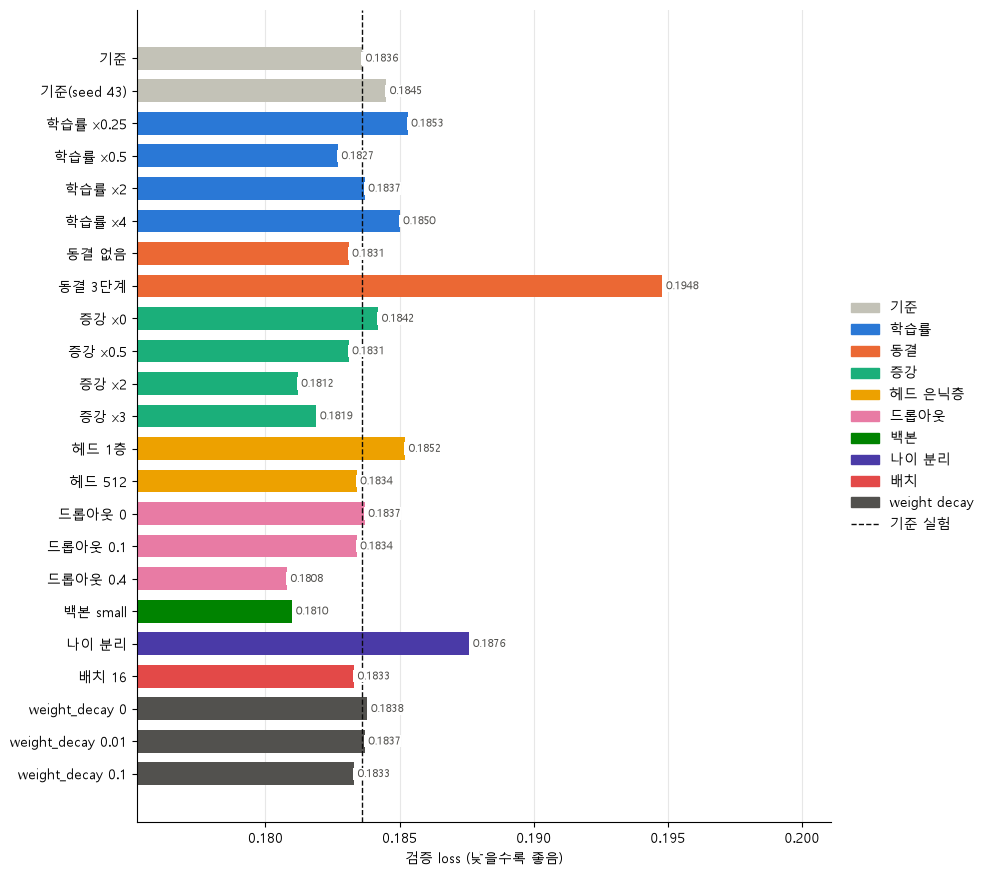

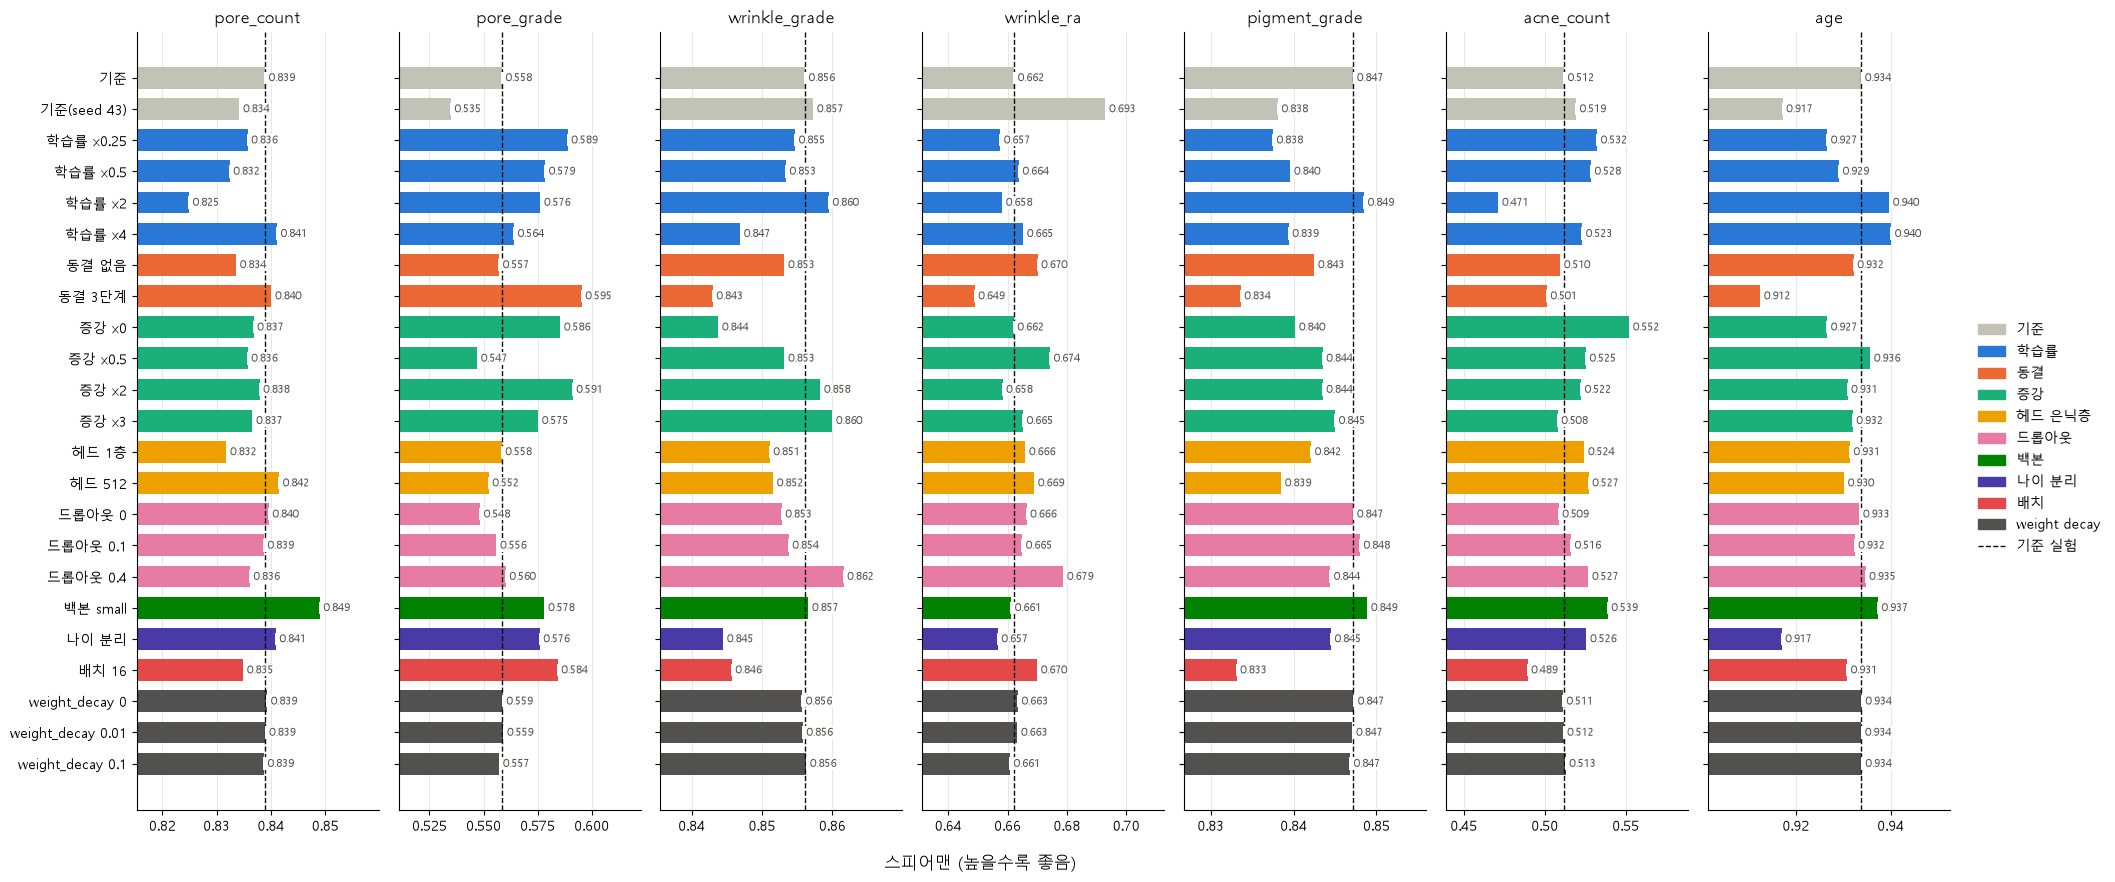

In [15]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

results = show_results()
if results:
    # 무엇을 바꾼 실험인지는 CSV의 설정 열로 판단한다. 아무것도 안 바꿨거나 seed만 바꾼 건 기준
    # 색은 순서 고정 팔레트(8색) + 9번째는 진회색, 기준은 옅은 회색
    GROUPS = {
        "lr_backbone": ("학습률", "#2a78d6"),
        "freeze_stages": ("동결", "#eb6834"),
        "aug_rotate": ("증강", "#1baf7a"),
        "head_hidden": ("헤드 은닉층", "#eda100"),
        "dropout": ("드롭아웃", "#e87ba4"),
        "backbone": ("백본", "#008300"),
        "detached_tasks": ("나이 분리", "#4a3aa7"),
        "batch_size": ("배치", "#e34948"),
        "weight_decay": ("weight decay", "#52514e"),
    }
    BASE = ("기준", "#c3c2b7")
    fixed = {"name", "when", "minutes", "epochs", "best_epoch", "val_loss", "mean"}

    def group_of(r):
        changed = {k for k, v in r.items() if k not in fixed and k not in TASK_NAMES and v}
        return next((GROUPS[k] for k in GROUPS if k in changed), BASE)

    names = [r["name"] for r in results]
    groups = [group_of(r) for r in results]
    colors = [color for _, color in groups]
    y = np.arange(len(results))
    handles = [Patch(color=color, label=name) for name, color in dict.fromkeys(groups)]
    handles.append(Line2D([0], [0], color="#0b0b0b", ls="--", lw=1, label="기준 실험"))

    def draw_bars(ax, values, digits):
        """실험마다 가로 막대 하나. 점선은 첫 줄(기준), 막대 끝에 값."""
        ax.barh(y, values, 0.7, color=colors)
        ax.axvline(values[0], color="#0b0b0b", ls="--", lw=1, zorder=1)
        for yi, value in zip(y, values):
            ax.text(value, yi, f" {value:.{digits}f}", va="center", fontsize=8, color="#52514e", zorder=3,
                    bbox=dict(facecolor="white", edgecolor="none", pad=0.5))
        span = max(values) - min(values) or 0.01
        ax.set_xlim(min(values) - span * 0.4, max(values) + span * 0.45)  # 차이가 작아서 왼쪽을 잘라 본다
        ax.grid(alpha=.3, axis="x")
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)

    height = 0.32 * len(results) + 1.5

    # 1) 검증 loss (모델 선택 기준)
    fig, ax = plt.subplots(figsize=(10, height))
    draw_bars(ax, [float(r["val_loss"]) for r in results], 4)
    ax.set_yticks(y, names)
    ax.invert_yaxis()  # CSV 순서대로 위에서 아래로
    ax.set_xlabel("검증 loss (낮을수록 좋음)")
    ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()

    # 2) 항목별 스피어맨 (보고용). 항목마다 한 칸, 실험 순서·색은 위와 같다
    tasks = [t for t in TASK_NAMES if t in results[0]]
    fig, axes = plt.subplots(1, len(tasks), figsize=(2.6 * len(tasks) + 1.5, height), sharey=True)
    for ax, task in zip(axes, tasks):
        draw_bars(ax, [float(r[task]) for r in results], 3)
        ax.set_title(task)
    axes[0].set_yticks(y, names)
    axes[0].invert_yaxis()
    fig.supxlabel("스피어맨 (높을수록 좋음)")
    fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()

# B. 최종 학습 (5-fold)

실험에서 정한 설정을 `FINAL`에 넣고 돌린다. 각도 3개를 모두 쓰므로 크롭이 2배가 된다.
맥 기준 13시간, RTX 5070 기준 최대 약 3.5시간 (에폭당 약 165초 × 15에폭 × 5 fold, 조기 종료되면 더 짧다).

In [5]:
FINAL = {**CFG, "views": ["F", "L", "R"], "epochs": 15,
         "aug_rotate": 20, "aug_scale": 0.1, "aug_bright": 0.2, "dropout": 0.4}

FOLDS_TO_RUN = 5

final_rows, final_test_rows = load_rows(FINAL)
print(f"학습 크롭 {len(final_rows):,}개 / 테스트 {len(final_test_rows):,}개")

fold_results = []
for fold, (tr, va) in enumerate(split_folds(final_rows, FINAL["folds"])):
    if fold >= FOLDS_TO_RUN:
        break
    print(f"\n[fold {fold}] 학습 {len(tr):,} / 검증 {len(va):,}")
    fold_results.append(train_fold(tr, va, FINAL, save_path=OUT_DIR / f"fold{fold}.pt"))

print("\n=== fold 요약 (사람 단위 순위 상관) ===")
for task in TASK_NAMES:
    scores = [b["results"][task]["spearman"] for b in fold_results if task in b["results"]]
    if scores:
        print(f"  {task:14s} {np.mean(scores):.3f} ± {np.std(scores):.3f}   {[round(s, 3) for s in scores]}")

학습 크롭 21,334개 / 테스트 4,431개

[fold 0] 학습 17,067 / 검증 4,267
  epoch  1 loss 학습 0.1987 검증 0.1935 | pore_coun 0.875  pore_grad 0.587  wrinkle_g 0.865  wrinkle_r 0.769  pigment_g 0.820  acne_coun 0.448  age 0.928 | 평균 0.756 (163초)
  epoch  2 loss 학습 0.1510 검증 0.1899 | pore_coun 0.886  pore_grad 0.600  wrinkle_g 0.868  wrinkle_r 0.767  pigment_g 0.832  acne_coun 0.480  age 0.927 | 평균 0.766 (144초)
  epoch  3 loss 학습 0.1339 검증 0.1859 | pore_coun 0.882  pore_grad 0.633  wrinkle_g 0.864  wrinkle_r 0.768  pigment_g 0.827  acne_coun 0.475  age 0.939 | 평균 0.770 (143초)
  epoch  4 loss 학습 0.1200 검증 0.1941 | pore_coun 0.877  pore_grad 0.612  wrinkle_g 0.871  wrinkle_r 0.770  pigment_g 0.829  acne_coun 0.499  age 0.932 | 평균 0.770 (143초)
  epoch  5 loss 학습 0.1069 검증 0.1904 | pore_coun 0.891  pore_grad 0.620  wrinkle_g 0.867  wrinkle_r 0.762  pigment_g 0.824  acne_coun 0.496  age 0.946 | 평균 0.772 (144초)
  epoch  6 loss 학습 0.0948 검증 0.1892 | pore_coun 0.888  pore_grad 0.604  wrinkle_g 0.866  wrinkle_r 0.7

  epoch  1 loss 학습 0.1998 검증 0.2020 | pore_coun 0.852  pore_grad 0.607  wrinkle_g 0.849  wrinkle_r 0.778  pigment_g 0.820  acne_coun 0.482  age 0.918 | 평균 0.758 (160초)
  epoch  2 loss 학습 0.1534 검증 0.1860 | pore_coun 0.853  pore_grad 0.618  wrinkle_g 0.865  wrinkle_r 0.783  pigment_g 0.842  acne_coun 0.442  age 0.928 | 평균 0.761 (144초)
  epoch  3 loss 학습 0.1361 검증 0.1782 | pore_coun 0.855  pore_grad 0.575  wrinkle_g 0.863  wrinkle_r 0.781  pigment_g 0.852  acne_coun 0.494  age 0.934 | 평균 0.765 (145초)
  epoch  4 loss 학습 0.1215 검증 0.1814 | pore_coun 0.857  pore_grad 0.588  wrinkle_g 0.870  wrinkle_r 0.785  pigment_g 0.854  acne_coun 0.506  age 0.935 | 평균 0.771 (144초)
  epoch  5 loss 학습 0.1074 검증 0.1807 | pore_coun 0.863  pore_grad 0.551  wrinkle_g 0.869  wrinkle_r 0.782  pigment_g 0.857  acne_coun 0.469  age 0.938 | 평균 0.761 (145초)
  epoch  6 loss 학습 0.0951 검증 0.1812 | pore_coun 0.866  pore_grad 0.535  wrinkle_g 0.866  wrinkle_r 0.784  pigment_g 0.861  acne_coun 0.476  age 0.938 | 평균 0.761

# C. 테스트 평가 + ailabtools 비교

학습·검증에 한 번도 쓰지 않은 165명이다. 같은 사람들을 상용 API로도 돌려놨으므로
**같은 정답 기준으로 순위 상관을 비교**한다. 단위가 달라서(우리는 기기 측정값, ailabtools는 자체 기준)
오차로는 비교할 수 없다.

In [6]:
checkpoints = sorted(OUT_DIR.glob("fold*.pt"))
print(f"불러온 체크포인트: {[p.name for p in checkpoints]}")

all_predictions = []
for path in checkpoints:
    saved = torch.load(path, map_location=DEVICE, weights_only=False)
    cfg = saved["cfg"]
    net = SkinModel(TASK_NAMES, backbone=cfg["backbone"], pretrained=False, freeze_stages=0,
                    head_hidden=cfg["head_hidden"], head_act=cfg["head_act"], dropout=cfg["dropout"]).to(DEVICE)
    net.load_state_dict(saved["model"])
    loader = make_loader(final_test_rows, saved["stats"], cfg, train=False)
    _, _, predictions = evaluate(net, loader, final_test_rows, saved["stats"], return_predictions=True)
    all_predictions.append(predictions)
    print(f"  {path.name} 완료")

# 항목별로 fold 예측을 평균 (앙상블)
ensemble = {}
for task in TASK_NAMES:
    parts = [p[task] for p in all_predictions if task in p]
    if not parts:
        continue
    keys, actual = parts[0][0], parts[0][2]
    pred = np.mean([p[1] for p in parts], axis=0)
    ensemble[task] = dict(keys=keys, pred=pred, actual=actual,
                          spearman=float(spearmanr(pred, actual).statistic),
                          pearson=float(pearsonr(pred, actual).statistic),
                          mae=float(np.abs(pred - actual).mean()))

print(f"\n{'항목':16s} {'스피어맨':>9s} {'피어슨':>8s} {'MAE':>10s} {'개수':>6s}")
for task, r in ensemble.items():
    print(f"  {task:14s} {r['spearman']:9.3f} {r['pearson']:8.3f} {r['mae']:10.1f} {len(r['keys']):6d}")

불러온 체크포인트: ['fold0.pt', 'fold1.pt', 'fold2.pt', 'fold3.pt', 'fold4.pt']
  fold0.pt 완료
  fold1.pt 완료
  fold2.pt 완료
  fold3.pt 완료
  fold4.pt 완료

항목                    스피어맨      피어슨        MAE     개수
  pore_count         0.847    0.835      174.3    330
  pore_grade         0.603    0.654        0.5    330
  wrinkle_grade      0.847    0.905        0.6    660
  wrinkle_ra         0.776    0.775        2.8    330
  pigment_grade      0.863    0.853        0.5    495
  acne_count         0.396    0.608        0.6    495
  age                0.947    0.944        4.1    990


항목               지표                  우리 모델  ailabtools     비교 개수
  pore_count     스피어맨                0.847       0.500       330
                 피어슨                 0.835       0.463       330
  pore_grade     스피어맨                0.603       0.363       330
                 켄달 τ-b              0.489       0.316       330
  wrinkle_grade  스피어맨                0.847       0.382       660
                 켄달 τ-b              0.709       0.324       660
  wrinkle_ra     스피어맨                0.776       0.271       330
                 켄달 τ-b              0.580       0.201       330
  pigment_grade  스피어맨                0.863       대응 없음       495
                 QWK                 0.800       대응 없음       495
                 ±1등급 정확도            0.972       대응 없음       495
  acne_count     스피어맨                0.396       대응 없음       495
                 MAE(개)              0.642       대응 없음       495
                 상수 예측 MAE(개)        0.709       대응 없음       495
  age            스피어맨    

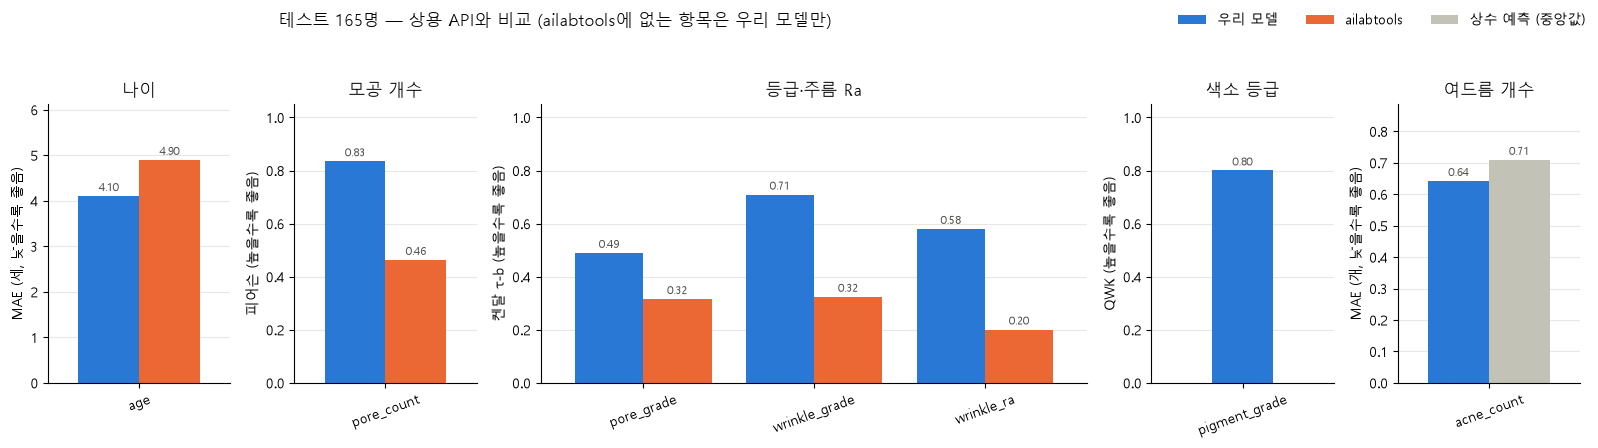

In [15]:
# ailabtools 결과 불러오기
ailab = {}
for sid in {s["subject_id"] for s in json.loads((AILAB_DIR / "test_subjects_165.json").read_text(encoding="utf-8"))["subjects"]}:
    path = AILAB_DIR / "raw" / f"{sid}.json"
    if path.exists():
        ailab[sid] = json.loads(path.read_text(encoding="utf-8"))["result"]

# (우리 항목, 부위) → ailabtools의 대응 값
AILAB_FIELDS = {
    ("pore_count", "l_cheek"): lambda r: r["enlarged_pore_count"]["left_cheek_count"],
    ("pore_count", "r_cheek"): lambda r: r["enlarged_pore_count"]["right_cheek_count"],
    ("pore_grade", "l_cheek"): lambda r: r["pores_left_cheek"]["value"],
    ("pore_grade", "r_cheek"): lambda r: r["pores_right_cheek"]["value"],
    ("wrinkle_grade", "forehead"): lambda r: r["forehead_wrinkle_severity"]["value"],
    ("wrinkle_grade", "glabella"): lambda r: r["glabella_wrinkle_severity"]["value"],
    ("wrinkle_grade", "l_eye"): lambda r: r["left_crows_feet_severity"]["value"],
    ("wrinkle_grade", "r_eye"): lambda r: r["right_crows_feet_severity"]["value"],
    ("wrinkle_ra", "l_eye"): lambda r: r["left_crows_feet_severity"]["value"],
    ("wrinkle_ra", "r_eye"): lambda r: r["right_crows_feet_severity"]["value"],
    **{("age", region): (lambda r: r["skin_age"]["value"]) for region in REGIONS},
}

from scipy.stats import kendalltau
from sklearn.metrics import cohen_kappa_score

# 항목마다 성격에 맞는 지표를 본다. 스피어맨은 모든 항목 공통이라 표에 함께 남긴다
#   나이: 단위가 같아서 MAE로 직접 비교할 수 있다 (+ 피어슨)
#   모공 개수: 연속형이라 피어슨
#   등급·주름 Ra: ailabtools는 척도(단계 수)가 달라서 순서만 비교한다 → 켄달 τ-b (동점이 많을 때 적합)
#   색소 등급·여드름: ailabtools에 없고 예측과 정답의 단위가 같아서 얼마나 맞혔는지 직접 잰다
#     색소 등급: 예측을 가장 가까운 등급으로 반올림한 뒤 QWK (멀리 틀릴수록 더 감점) + ±1등급 정확도
#     여드름: MAE. 대부분 0~1개라 "항상 중앙값을 찍는" 상수 예측의 MAE를 기준선으로 함께 본다
KENDALL_TASKS = {"pore_grade", "wrinkle_grade", "wrinkle_ra"}
PIGMENT_GRADES = (0, 5)
PANELS = [  # (칸 제목, 항목, 그래프에 쓸 지표, 세로축 이름)
    ("나이", ["age"], "MAE(세)", "MAE (세, 낮을수록 좋음)"),
    ("모공 개수", ["pore_count"], "피어슨", "피어슨 (높을수록 좋음)"),
    ("등급·주름 Ra", ["pore_grade", "wrinkle_grade", "wrinkle_ra"], "켄달 τ-b", "켄달 τ-b (높을수록 좋음)"),
    ("색소 등급", ["pigment_grade"], "QWK", "QWK (높을수록 좋음)"),
    ("여드름 개수", ["acne_count"], "MAE(개)", "MAE (개, 낮을수록 좋음)"),
]
LOWER_IS_BETTER = {"MAE(세)", "MAE(개)"}
BASELINES = {"MAE(개)": "상수 예측 MAE(개)"}  # 그래프에 회색 막대로 함께 그릴 기준선


def compare_metrics(task, pred, actual):
    metrics = {"스피어맨": float(spearmanr(pred, actual).statistic)}
    if task in KENDALL_TASKS:
        metrics["켄달 τ-b"] = float(kendalltau(pred, actual).statistic)
    elif task == "pigment_grade":
        grade = np.clip(np.rint(pred), *PIGMENT_GRADES).astype(int)
        metrics["QWK"] = float(cohen_kappa_score(actual.astype(int), grade, weights="quadratic"))
        metrics["±1등급 정확도"] = float(np.mean(np.abs(grade - actual) <= 1))
    elif task == "acne_count":
        metrics["MAE(개)"] = float(np.abs(pred - actual).mean())
        metrics["상수 예측 MAE(개)"] = float(np.abs(actual - np.median(actual)).mean())
    else:
        metrics["피어슨"] = float(pearsonr(pred, actual).statistic)
    if task == "age":
        metrics["MAE(세)"] = float(np.abs(pred - actual).mean())
    return metrics


print(f"{'항목':16s} {'지표':14s} {'우리 모델':>10s} {'ailabtools':>11s} {'비교 개수':>9s}")
scores = {}  # 항목 → (우리 모델 지표, ailabtools 지표 또는 None)
for task, r in ensemble.items():
    pairs = [(our, r["actual"][i], AILAB_FIELDS[(task, region)](ailab[subject]))
             for i, ((subject, region), our) in enumerate(zip(r["keys"], r["pred"]))
             if (task, region) in AILAB_FIELDS and subject in ailab]
    if len(pairs) >= 20:
        ours, actual, theirs = map(np.array, zip(*pairs))
        scores[task] = (compare_metrics(task, ours, actual), compare_metrics(task, theirs, actual))
        n = len(pairs)
    else:  # ailabtools에 대응 값이 없으면 우리 모델만 테스트 전체로 잰다
        scores[task] = (compare_metrics(task, r["pred"], r["actual"]), None)
        n = len(r["keys"])
    ours_m, theirs_m = scores[task]
    for i, name in enumerate(ours_m):
        theirs_text = f"{theirs_m[name]:11.3f}" if theirs_m else f"{'대응 없음':>11s}"
        print(f"  {task if i == 0 else '':14s} {name:14s} {ours_m[name]:10.3f} {theirs_text} {n:9d}")

if scores:
    SIDES = [(-0.2, 0, "#2a78d6", "우리 모델"), (0.2, 1, "#eb6834", "ailabtools")]
    fig, axes = plt.subplots(1, len(PANELS), figsize=(16, 4.5), gridspec_kw={"width_ratios": [1, 1, 3, 1, 1]})
    for ax, (title, tasks, metric, ylabel) in zip(axes, PANELS):
        tasks = [t for t in tasks if t in scores]
        x = np.arange(len(tasks))
        paired = metric in BASELINES or any(scores[t][1] for t in tasks)  # 막대가 하나뿐이면 가운데에
        bars_to_draw = [(offset, [(xi + (offset if paired else 0), scores[t][side][metric])
                                  for xi, t in zip(x, tasks) if scores[t][side]],
                         color, label) for offset, side, color, label in SIDES]
        if metric in BASELINES:  # ailabtools 자리에 상수 예측 기준선
            bars_to_draw.append((0.2, [(xi + 0.2, scores[t][0][BASELINES[metric]]) for xi, t in zip(x, tasks)],
                                 "#c3c2b7", "상수 예측 (중앙값)"))
        values = []
        for _, shown, color, label in bars_to_draw:
            if not shown:
                continue
            bars = ax.bar([p for p, _ in shown], [v for _, v in shown], 0.4, color=color, label=label)
            ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2, color="#52514e")
            values += [v for _, v in shown]
        top = max(values) * 1.25 if metric in LOWER_IS_BETTER else 1.05
        ax.set_ylim(min(0, min(values) - 0.05), top)
        ax.set_xlim(-0.6, len(tasks) - 0.4)  # 칸마다 막대 폭을 같게
        ax.set_xticks(x, tasks, rotation=20)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=.3, axis="y")
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
    handles = {}
    for ax in axes:
        for handle, label in zip(*ax.get_legend_handles_labels()):
            handles.setdefault(label, handle)
    fig.legend(handles.values(), handles.keys(), loc="upper right", frameon=False, ncol=3)
    fig.suptitle("테스트 165명 — 상용 API와 비교 (ailabtools에 없는 항목은 우리 모델만)", x=0.35)
    plt.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()

# D. 서버 배포용 내보내기

앱이 크롭을 만들어 보내고 서버는 추론만 하는 구조다. 서버에 올릴 것은 세 개다.

- **`skin.onnx`** — 연산 그래프. `model.py` 없이 ONNX Runtime만으로 실행된다 (1MB 안팎)
- **`skin.onnx.data`** — 가중치 (약 110MB). torch가 가중치를 따로 저장한다. `skin.onnx`와 같은 폴더에 둬야 로드된다
- **`meta.json`** — 예측을 원래 단위로 되돌릴 기준(stats)과 입력 규격. 가중치는 없다 (수 KB)

ONNX Runtime이 PyTorch CPU보다 5배 빠르다 (6부위 2.2초 → 0.4초).

**배포용 모델은 보통 전체 데이터로 다시 학습한다.** 교차검증은 설정과 에폭 수를 고르는 용도이고,
5개를 앙상블하면 메모리·시간이 5배인데 성능 향상은 1~2%다.
아래 `DEPLOY_CHECKPOINT`를 배포할 체크포인트로 지정하면 된다.

In [8]:
DEPLOY_CHECKPOINT = OUT_DIR / "fold0.pt"   # 배포할 체크포인트
EXPORT_DIR = OUT_DIR / "deploy"
EXPORT_DIR.mkdir(exist_ok=True)

saved = torch.load(DEPLOY_CHECKPOINT, map_location="cpu", weights_only=False)
cfg = saved["cfg"]
net = SkinModel(TASK_NAMES, backbone=cfg["backbone"], pretrained=False, freeze_stages=0,
                head_hidden=cfg["head_hidden"], head_act=cfg["head_act"], dropout=cfg["dropout"])
net.load_state_dict(saved["model"])
net.eval()

# 부위마다 입력 크기가 달라서 세로·가로를 고정하지 않고 내보낸다.
# ConvNeXt는 합성곱 + 전역 평균 풀링이라 크기가 달라도 항상 768개 특징이 나온다.
onnx_path = EXPORT_DIR / "skin.onnx"
torch.onnx.export(
    net, torch.randn(1, 3, 576, 512), str(onnx_path),
    input_names=["crop"], output_names=["pred"],
    dynamic_axes={"crop": {0: "batch", 2: "height", 3: "width"}, "pred": {0: "batch"}},
    opset_version=18,  # torch 2.9+의 내보내기는 18 이상만 지원한다
)

meta = {
    "version": datetime.now().strftime("%Y-%m-%d"),
    "tasks": TASK_NAMES,
    "regions": REGIONS,
    # 예측값 → 원래 단위: log면 expm1(pred * std + mean), 아니면 pred * std + mean
    "stats": {task: {"mean": saved["stats"][task][0], "std": saved["stats"][task][1],
                     "log": TASKS[task]["log"], "regions": TASKS[task]["regions"]}
              for task in TASK_NAMES if task in saved["stats"]},
    # 서버가 크롭을 모델 입력으로 만들 때 지켜야 하는 규격
    "input": {
        "canvas": {region: list(CANVAS[region]) for region in REGIONS},   # (가로, 세로)
        "target_face_height": face_regions.TARGET_FACE_HEIGHT,
        "mirror_right": cfg["mirror_right"],     # r_ 부위는 좌우 반전해서 넣는다
        "pixel_mean": list(PIXEL_MEAN),
        "pixel_std": list(PIXEL_STD),
        "mask_fill": 0,                          # 다각형 밖은 정규화 '후' 0 (= 평균 색)
    },
    "train": {"backbone": cfg["backbone"], "views": cfg["views"], "epochs": saved["cfg"]["epochs"],
              "checkpoint": DEPLOY_CHECKPOINT.name},
}
(EXPORT_DIR / "meta.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")

data_path = onnx_path.with_name(onnx_path.name + ".data")
print(f"skin.onnx       {onnx_path.stat().st_size / 1e6:.1f} MB  (연산 그래프)")
print(f"skin.onnx.data  {data_path.stat().st_size / 1e6:.0f} MB  (가중치)")
print(f"meta.json       {(EXPORT_DIR / 'meta.json').stat().st_size / 1024:.1f} KB")

C:\Users\user\AppData\Local\Temp\ipykernel_27420\304619052.py:15: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0926 15:53:28.610000 27420 Lib\site-packages\torch\utils\flop_counter.py:113] triton not found; flop counting will not work for triton kernels


[torch.onnx] Obtain model graph for `SkinModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SkinModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
skin.onnx       0.9 MB  (연산 그래프)
skin.onnx.data  117 MB  (가중치)
meta.json       2.5 KB


In [9]:
# 내보낸 ONNX가 PyTorch와 같은 값을 내는지, 부위별 크기가 다 되는지 확인
import onnxruntime as ort

session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
print(f"{'부위':10s} {'입력':>12s} {'torch와 차이':>12s} {'시간':>8s}")
total = 0
for region in REGIONS:
    width, height = CANVAS[region]
    x = np.random.randn(1, 3, height, width).astype(np.float32)
    with torch.no_grad():
        reference = net(torch.from_numpy(x)).numpy()
    started = time.perf_counter()
    output = session.run(None, {"crop": x})[0]
    elapsed = (time.perf_counter() - started) * 1000
    total += elapsed
    print(f"  {region:8s} {width}x{height:<8} {np.abs(output - reference).max():12.6f} {elapsed:7.0f} ms")
print(f"\n6부위 합계 {total / 1000:.1f}초 (사진 3장이면 14크롭이라 약 {total * 14 / 6 / 1000:.1f}초)")

print("""
서버에 올릴 것
  deploy/skin.onnx        연산 그래프 (model.py 불필요)
  deploy/skin.onnx.data   가중치 (skin.onnx와 같은 폴더에)
  deploy/meta.json        stats + 입력 규격

서버가 할 일
  1. 앱에서 받은 부위 크롭 + 얼굴 세로 길이
  2. meta.json 규격대로 정규화 (배율 통일 → 캔버스 → r_ 부위 반전 → 픽셀 정규화)
  3. session.run(None, {"crop": x}) → (1, 7)
  4. stats로 원래 단위 복원 → 같은 부위끼리 평균 → 최종 점수
""")

부위                   입력    torch와 차이       시간
  forehead 608x288          0.000001     144 ms
  glabella 192x160          0.000001      21 ms
  l_eye    192x224          0.000001      28 ms
  r_eye    192x224          0.000001      28 ms
  l_cheek  512x576          0.000001     240 ms
  r_cheek  512x576          0.000001     240 ms

6부위 합계 0.7초 (사진 3장이면 14크롭이라 약 1.6초)

서버에 올릴 것
  deploy/skin.onnx        연산 그래프 (model.py 불필요)
  deploy/skin.onnx.data   가중치 (skin.onnx와 같은 폴더에)
  deploy/meta.json        stats + 입력 규격

서버가 할 일
  1. 앱에서 받은 부위 크롭 + 얼굴 세로 길이
  2. meta.json 규격대로 정규화 (배율 통일 → 캔버스 → r_ 부위 반전 → 픽셀 정규화)
  3. session.run(None, {"crop": x}) → (1, 7)
  4. stats로 원래 단위 복원 → 같은 부위끼리 평균 → 최종 점수

